# Análisis de Inferencia de ViT

Este notebook analiza las métricas de rendimiento del modelo Vision Transformer (ViT) utilizando diferentes configuraciones de hardware.

## Configuración experimental
- **Modelo**: Vision Transformer (ViT)
- **Modo de ejecución**: Inferencia
- **Varía**: Número de GPUs / uso de CPU y tamaño de batch
- **Dos modos por configuración**: Ejecuciones estándar (para medir el rendimiento real) y ejecuciones con *profiling* (para analizar cuellos de botella).
- **Métricas principales**: Imágenes por segundo (Throughput) y consumo de memoria VRAM.

Importación de librerías y configuración

In [7]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuraciones estéticas globales para los gráficos
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# Gestión de directorios para guardar gráficos
IMAGES_DIR = Path.cwd() / 'images'
if not IMAGES_DIR.exists():
    IMAGES_DIR.mkdir(parents=True)

Carga y preparación de los datos

In [37]:
def recopilar_datos_estadisticos(base_dir="results/image/cuda"):
    datos = []
    
    if not os.path.exists(base_dir):
        print(f"La ruta {base_dir} no existe. Comprueba la ubicación del notebook.")
        return pd.DataFrame()
        
    for hw_folder in os.listdir(base_dir):
        hw_path = os.path.join(base_dir, hw_folder)
        if os.path.isdir(hw_path):
            for mode_folder in os.listdir(hw_path):
                mode_path = os.path.join(hw_path, mode_folder)
                if os.path.isdir(mode_path):
                    stats_file = os.path.join(mode_path, "stats.json")
                    if os.path.exists(stats_file):
                        with open(stats_file, 'r') as f:
                            data = json.load(f)

                            config_model_str = data.get("config", {}).get("model", "{}")
                            config_model = json.loads(config_model_str)
                            
                            fila = {
                                "Hardware": hw_folder,
                                "Modo": mode_folder,
                                "Batch_Size": config_model.get("per_device_batch_size", 0),
                                "Tiempo_Total_Segundos": data.get("elapsed_seconds", 0),
                                "Imagenes_por_Segundo": data.get("throughput_images_per_second", 0),
                                "Memoria_RSS_MB": data.get("memory", {}).get("rss_mb", {}).get("max", 0),
                                "Memoria_VRAM_MB": data.get("memory", {}).get("cuda_allocated_mb", {}).get("max", 0)
                            }
                            datos.append(fila)                   
    return pd.DataFrame(datos)

# Cargar los datos y filtrar solo las ejecuciones sin el profiler
# Cargar los datos
df_resultados = recopilar_datos_estadisticos("results/image/cuda")

display(df_resultados)

,Hardware,Modo,Batch_Size,Tiempo_Total_Segundos,Imagenes_por_Segundo,Memoria_RSS_MB,Memoria_VRAM_MB
0,1xCPU,no_profile,32,20.9801,3.0505,1712.031250,0.000000
1,1xCPU,profile,32,20.9570,3.0539,2029.988281,0.000000
2,1xGPU,no_profile,32,3.5975,1091.0399,1532.304688,373.802734
3,1xGPU,profile,32,3.8340,1023.7264,1554.562500,373.802734
4,2xGPU,no_profile,32,1.8996,2088.8179,1910.382812,701.802734
5,2xGPU,profile,32,2.6511,1496.7621,1964.656250,701.802734
6,3xGPU,no_profile,32,1.3629,2887.8796,2001.132812,701.802734
7,3xGPU,profile,32,1.8039,2181.9193,2033.171875,701.802734
8,4xGPU,no_profile,32,1.0289,3856.6441,1989.894531,701.802734
9,4xGPU,profile,32,1.4763,2687.8469,2030.480469,701.802734


In [38]:
# Lista para guardar las filas de datos
mem_rows = []
ruta_base = Path("results/image/cuda")

if ruta_base.exists():
    for filepath in ruta_base.rglob("*.json"):
        try:
            with open(filepath, 'r') as f:
                stats = json.load(f)
            
            # Identificar hardware y modo según la estructura de carpetas
            hw_folder = filepath.parent.parent.name
            modo_folder = filepath.parent.name.lower()
            
            if "no_profile" in modo_folder:
                modo = "Sin Profiling"
            elif "profile" in modo_folder:
                modo = "Con Profiling"
            else:
                is_profile = stats.get('profile', {}).get('enabled', False)
                modo = "Con Profiling" if is_profile else "Sin Profiling"
            
            # Extraer el bloque de memoria
            mem_data = stats.get('memory', {})
            if not mem_data:
                continue
                
            cuda = mem_data.get('cuda_allocated_mb', {})
            rss  = mem_data.get('rss_mb', {})
            
            mem_rows.append({
                'Hardware': hw_folder, 
                'Modo': modo,
                'CUDA Min (GB)':  round(cuda.get('min',    0) / 1024, 2),
                'CUDA Mean (GB)': round(cuda.get('mean',   0) / 1024, 2),
                'CUDA Max (GB)':  round(cuda.get('max',    0) / 1024, 2),
                'CUDA Std (GB)':  round(cuda.get('stddev', 0) / 1024, 3),
                'RSS Mean (GB)':  round(rss.get('mean',    0) / 1024, 2),
                'RSS Max (GB)':   round(rss.get('max',     0) / 1024, 2),
            })
        except Exception as e:
            print(f"Error procesando {filepath.name}: {e}")

# Crear la tabla y aplicar los estilos
if mem_rows:
    mem_df = pd.DataFrame(mem_rows)
    
    # Ordenar los datos y establecer el índice doble igual que en NLP
    mem_df = mem_df.sort_values(by=['Hardware', 'Modo']).set_index(['Hardware', 'Modo'])
    
    # Mostrar la tabla con el gradiente de color naranja basado en el uso máximo de VRAM
    display(mem_df.style.background_gradient(subset=['CUDA Max (GB)'], cmap='Oranges'))
else:
    print("No se encontraron datos de memoria en la ruta especificada.")

## Sobrecarga del profiling

El proceso de *profiling* introduce una penalización en el rendimiento debido a la recolección de trazas y sincronizaciones de CUDA. A continuación, comparamos las imágenes por segundo procesadas en ejecuciones normales frente a las perfiladas para cuantificar esta sobrecarga.

Asegúrate de que la columna 'Profiling' existe y es booleana.


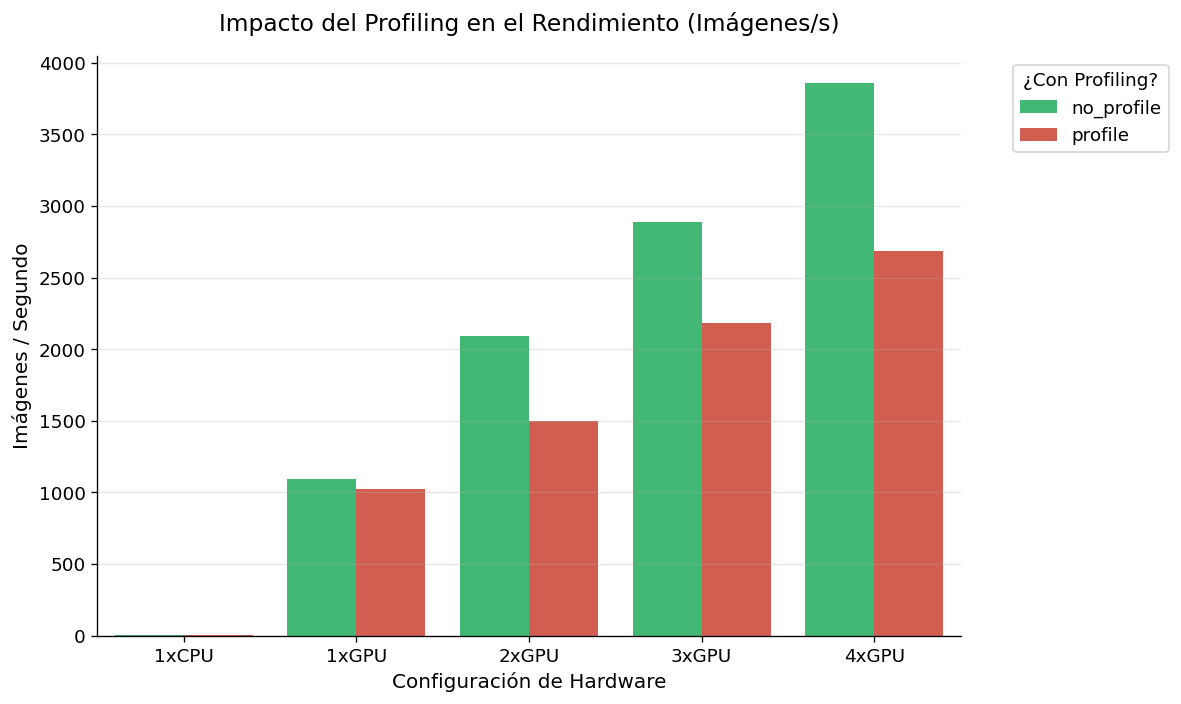

In [36]:
# Filtrar datos comparativos (asegúrate de que df_resultados tiene la columna 'Profiling')
df_comparativa = df_resultados.copy()

plt.figure(figsize=(10, 6))
barplot_prof = sns.barplot(
    data=df_comparativa, 
    x="Hardware", 
    y="Imagenes_por_Segundo", 
    hue="Modo", 
    palette=["#2ecc71", "#e74c3c"] # Verde (Sin profiling) y Rojo (Con profiling)
)

plt.title('Impacto del Profiling en el Rendimiento (Imágenes/s)', fontsize=14, pad=15)
plt.xlabel('Configuración de Hardware', fontsize=12)
plt.ylabel('Imágenes / Segundo', fontsize=12)
plt.legend(title='¿Con Profiling?', bbox_to_anchor=(1.05, 1), loc='upper left')

# Calcular y mostrar el % de sobrecarga sobre las barras
# (Requiere agrupar los datos temporalmente para la comparativa)
try:
    for hw in df_comparativa['Hardware'].unique():
        val_normal = df_comparativa[(df_comparativa['Hardware'] == hw) & (df_comparativa['Profiling'] == False)]['Imagenes_por_Segundo'].mean()
        val_prof = df_comparativa[(df_comparativa['Hardware'] == hw) & (df_comparativa['Profiling'] == True)]['Imagenes_por_Segundo'].mean()
        
        if pd.notna(val_normal) and pd.notna(val_prof) and val_normal > 0:
            sobrecarga = (1 - (val_prof / val_normal)) * 100
            print(f"Sobrecarga en {hw}: {sobrecarga:.2f}%")
except KeyError:
    print("Asegúrate de que la columna 'Profiling' existe y es booleana.")

plt.tight_layout()
plt.show()

## Eventos de perfilado de CUDA

Analizamos las operaciones internas que consumen más tiempo de CPU (sincronizaciones, lanzamientos de kernels) durante la inferencia para identificar los cuellos de botella exactos en cada configuración de hardware.

In [34]:
import re
import json
import pandas as pd
from pathlib import Path
from IPython.display import display

def parse_key_averages(items: list) -> pd.DataFrame:
    """Extrae las métricas de tiempo de los strings generados por PyTorch Profiler."""
    pattern = re.compile(
        r'key=(.+?)'
        r'\s+self_cpu_time=([0-9.]+)(ms|us|ns)'
        r'\s+cpu_time=([0-9.]+)(ms|us|ns)'
        r'\s+self_cuda_time=([0-9.]+)(ms|us|ns)'
        r'\s+cuda_time=([0-9.]+)(ms|us|ns)'
    )
    rows = []
    
    def to_us(value: str, unit: str) -> float:
        v = float(value)
        if unit == 'ms': return v * 1e3
        if unit == 'us': return v
        if unit == 'ns': return v / 1e3
        return v

    for item in items:
        m = pattern.search(item)
        if m:
            rows.append({
                'Operacion': m.group(1).strip(),
                'Self_CPU_us': to_us(m.group(2), m.group(3)),
                'Self_CUDA_us': to_us(m.group(6), m.group(7))
            })
    return pd.DataFrame(rows)


# 1. Construir el diccionario leyendo los JSON de profiling reales
ruta_base = Path("results/image/cuda")
lista_jsons_perfilados = {}

if ruta_base.exists():
    for filepath in ruta_base.rglob("*.json"):
        # Filtramos solo los archivos que están en la carpeta de profiling
        if "profile" in filepath.parent.name.lower() and "no_profile" not in filepath.parent.name.lower():
            try:
                with open(filepath, 'r') as f:
                    stats = json.load(f)
                    
                    # Verificamos que realmente contiene los strings de key_averages
                    if stats.get('profile', {}).get('key_averages_items'):
                        hw = filepath.parent.parent.name
                        lista_jsons_perfilados[hw] = stats
            except Exception as e:
                print(f"Error leyendo {filepath.name}: {e}")

# 2. Procesar los datos y mostrar el Top 10 por Hardware
if not lista_jsons_perfilados:
    print("No se encontraron datos de profiling. Verifica las rutas y los archivos.")
else:
    # Ordenamos las claves (1xCPU, 1xGPU...) para que aparezcan en orden lógico
    for hw in sorted(lista_jsons_perfilados.keys()):
        datos = lista_jsons_perfilados[hw]
        items = datos.get('profile', {}).get('key_averages_items', [])
        
        if items:
            df_operaciones = parse_key_averages(items)
            # Obtenemos las 10 operaciones que más tiempo de CPU consumen
            top_10 = df_operaciones.nlargest(10, 'Self_CPU_us')
            
            print(f"\n=== Top 10 Operaciones en {hw} ===")
            display(top_10)


=== Top 10 Operaciones en 1xCPU ===


,Operacion,Self_CPU_us,Self_CUDA_us
32,aten::gelu,411083.0,0.0
25,aten::copy_,340811.0,0.0
0,enumerate(DataLoader)#_MultiProcessingDataLoad...,117073.0,0.0
6,aten::mkldnn_convolution,78248.0,0.0
19,aten::add,71337.0,0.0
22,aten::native_layer_norm,67843.0,0.0
27,cudaHostAlloc,27616.0,0.0
15,aten::cat,6775.0,0.0
23,aten::linear,2525.0,0.0
11,aten::view,1639.0,0.0



=== Top 10 Operaciones en 1xGPU ===


,Operacion,Self_CPU_us,Self_CUDA_us
5,cudaStreamSynchronize,41559.000,0.0
6,cudaLaunchKernel,25882.000,0.0
14,cuLaunchKernel,20430.000,0.0
23,cudaHostAlloc,7321.000,0.0
3,cudaMemcpyAsync,2296.000,0.0
1,Activity Buffer Request,2132.000,0.0
0,cudaPointerGetAttributes,1937.000,0.0
12,cudaDeviceGetAttribute,947.877,0.0
13,cudaMemsetAsync,529.968,0.0
15,cudaStreamIsCapturing,435.917,0.0



=== Top 10 Operaciones en 2xGPU ===


,Operacion,Self_CPU_us,Self_CUDA_us
10,DistributedDataParallel.forward,106431.0,0.0
2,enumerate(DataLoader)#_MultiProcessingDataLoad...,98048.0,0.0
9,cudaStreamSynchronize,21395.0,0.0
15,cudaLaunchKernel,16599.0,0.0
38,cuLaunchKernel,11263.0,0.0
32,aten::empty,11115.0,0.0
34,aten::linear,10925.0,0.0
23,aten::transpose,10277.0,0.0
31,aten::native_layer_norm,8440.0,22902.0
19,aten::view,6732.0,0.0



=== Top 10 Operaciones en 3xGPU ===


,Operacion,Self_CPU_us,Self_CUDA_us
52,cudaDeviceSynchronize,954102.0,12.832
2,enumerate(DataLoader)#_MultiProcessingDataLoad...,97564.0,0.000
10,DistributedDataParallel.forward,65830.0,0.000
36,aten::addmm,25571.0,963159.000
9,cudaStreamSynchronize,13937.0,0.000
15,cudaLaunchKernel,13036.0,0.000
39,cuLaunchKernel,9018.0,0.000
32,aten::empty,7055.0,0.000
22,aten::transpose,6661.0,0.000
34,aten::linear,6565.0,0.000



=== Top 10 Operaciones en 4xGPU ===


,Operacion,Self_CPU_us,Self_CUDA_us
53,cudaDeviceSynchronize,720422.0,0.0
2,enumerate(DataLoader)#_MultiProcessingDataLoad...,93670.0,0.0
10,DistributedDataParallel.forward,56819.0,0.0
37,aten::addmm,17813.0,728481.0
9,cudaStreamSynchronize,10672.0,0.0
15,cudaLaunchKernel,7968.0,0.0
33,aten::empty,5520.0,0.0
40,cuLaunchKernel,5436.0,0.0
35,aten::linear,5335.0,0.0
23,aten::transpose,4964.0,0.0


Gráfico de Rendimiento

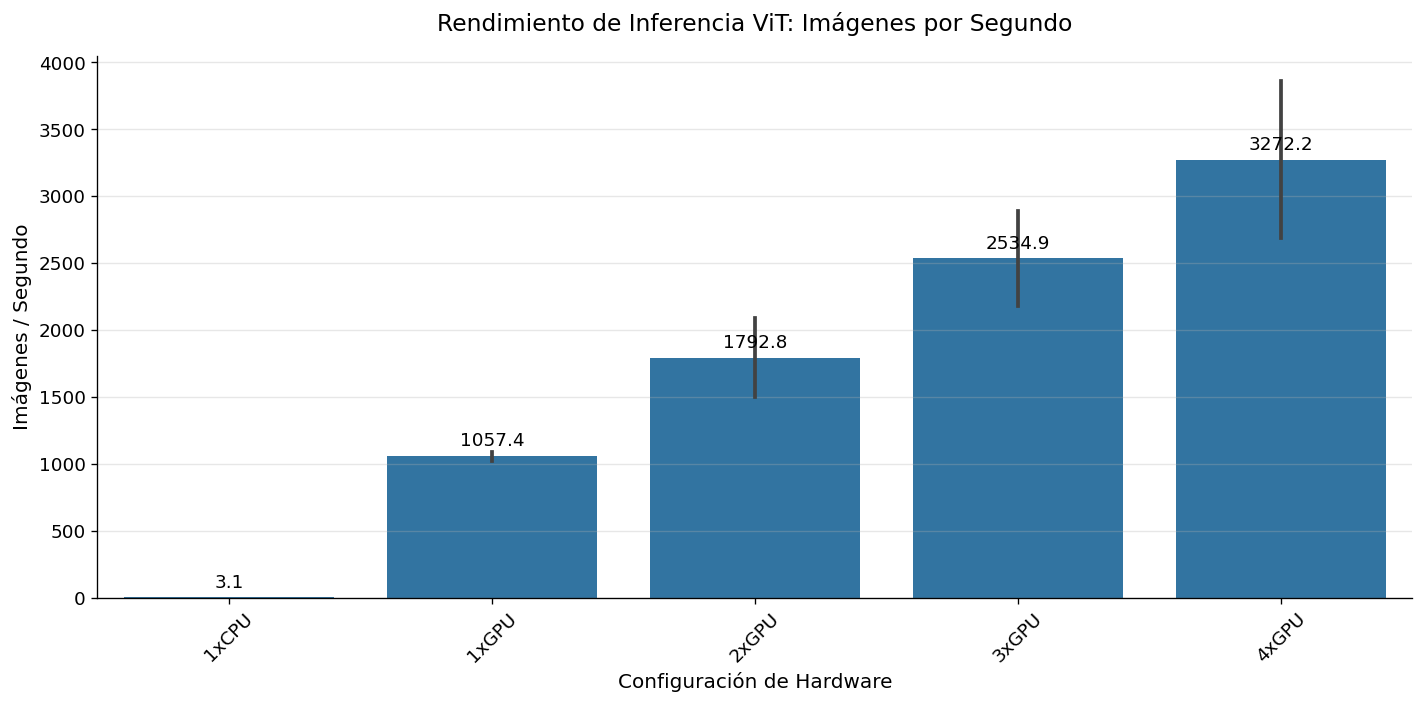

In [15]:
plt.figure(figsize=(12, 6))
barplot1 = sns.barplot(data=df_resultados, x="Hardware", y="Imagenes_por_Segundo")

plt.title('Rendimiento de Inferencia ViT: Imágenes por Segundo', fontsize=14, pad=15)
plt.xlabel('Configuración de Hardware', fontsize=12)
plt.ylabel('Imágenes / Segundo', fontsize=12)
plt.xticks(rotation=45)

# Añadir valores numéricos sobre las barras
for p in barplot1.patches:
    barplot1.annotate(format(p.get_height(), '.1f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.tight_layout()
plt.show()

Gráfico de Consumo de Memoria

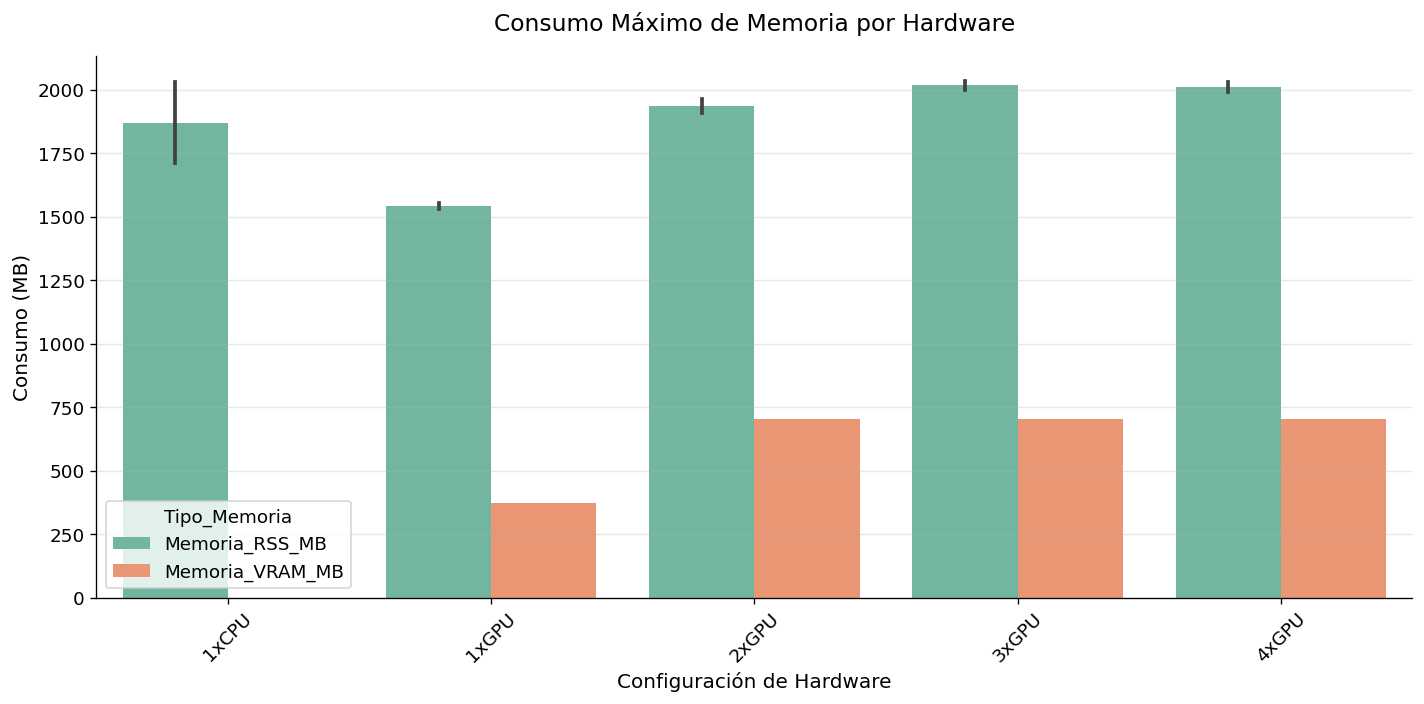

In [16]:
# Reestructurar la tabla para poder pintar dos barras juntas (RAM y VRAM)
df_memoria = df_resultados.melt(
    id_vars=["Hardware"], 
    value_vars=["Memoria_RSS_MB", "Memoria_VRAM_MB"],
    var_name="Tipo_Memoria", 
    value_name="Consumo_MB"
)

plt.figure(figsize=(12, 6))
barplot2 = sns.barplot(data=df_memoria, x="Hardware", y="Consumo_MB", hue="Tipo_Memoria", palette="Set2")

plt.title('Consumo Máximo de Memoria por Hardware', fontsize=14, pad=15)
plt.xlabel('Configuración de Hardware', fontsize=12)
plt.ylabel('Consumo (MB)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Grafica tiempo de ejecución

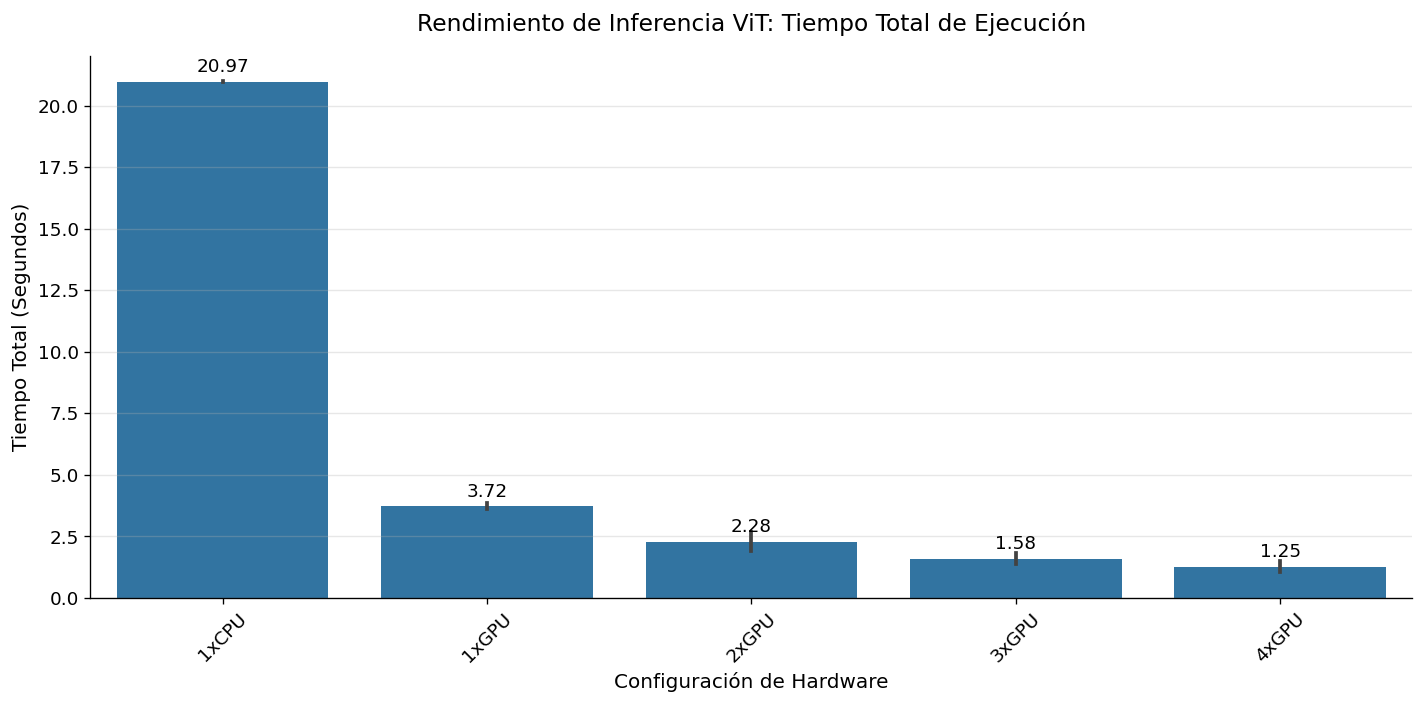

In [17]:
plt.figure(figsize=(12, 6))
# Usamos la columna real Tiempo_Total_Segundos generada en tu dataset
barplot_tiempo = sns.barplot(data=df_resultados, x="Hardware", y="Tiempo_Total_Segundos")

plt.title('Rendimiento de Inferencia ViT: Tiempo Total de Ejecución', fontsize=14, pad=15)
plt.xlabel('Configuración de Hardware', fontsize=12)
plt.ylabel('Tiempo Total (Segundos)', fontsize=12)
plt.xticks(rotation=45)

# Añadir valores numéricos sobre las barras
for p in barplot_tiempo.patches:
    barplot_tiempo.annotate(format(p.get_height(), '.2f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.tight_layout()
plt.show()

Gráfica impacto del tamaño del Batch

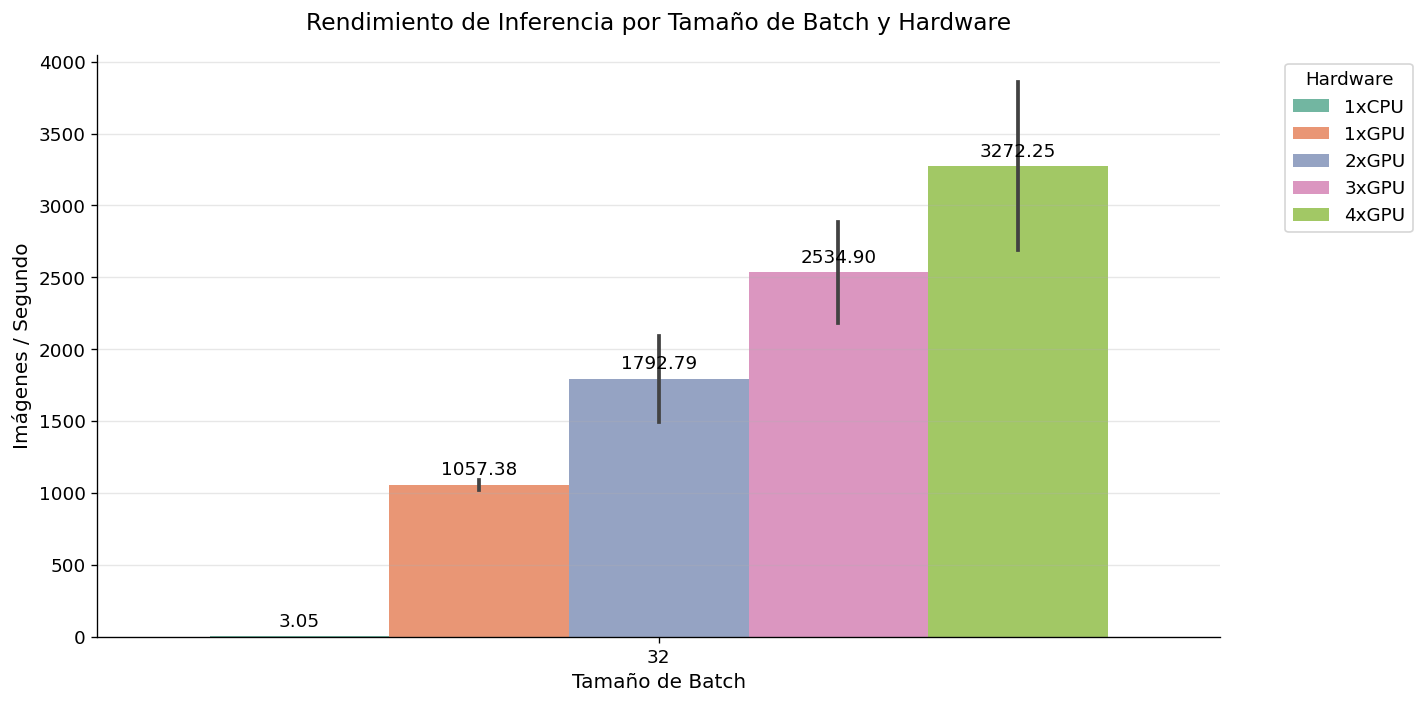

In [18]:
plt.figure(figsize=(12, 6))

# Crear el gráfico de barras agrupado
barplot_batch = sns.barplot(
    data=df_resultados, 
    x="Batch_Size", 
    y="Imagenes_por_Segundo", 
    hue="Hardware", 
    palette="Set2"
)

plt.title('Rendimiento de Inferencia por Tamaño de Batch y Hardware', fontsize=14, pad=15)
plt.xlabel('Tamaño de Batch', fontsize=12)
plt.ylabel('Imágenes / Segundo', fontsize=12)

# Añadir valores numéricos sobre las barras
for p in barplot_batch.patches:
    # Solo anotamos si la barra tiene una altura mayor que 0
    if p.get_height() > 0:
        barplot_batch.annotate(
            format(p.get_height(), '.2f'), 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', 
            va='center', 
            xytext=(0, 9), 
            textcoords='offset points'
        )

# Mover la leyenda fuera del gráfico para que no tape las barras
plt.legend(title='Hardware', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Latencia y grafica de distribución de tiempos 

Buscando archivos en:
c:\Users\rafel\OneDrive\Escritorio\MASTER_UM_IA\cuatri2\infraestructuras DL\practica1\infradeep\results\image\cuda

    Hardware      Profiling  Paso  Latencia_Segundos
0      1xCPU  Sin Profiling     0          10.458687
1      1xCPU  Sin Profiling     1          10.402305
2      1xCPU  Con Profiling     0          10.401458
3      1xCPU  Con Profiling     1          10.378481
4      1xGPU  Sin Profiling     0           0.028920
..       ...            ...   ...                ...
513    4xGPU  Con Profiling    26           0.027166
514    4xGPU  Con Profiling    27           0.027341
515    4xGPU  Con Profiling    28           0.027146
516    4xGPU  Con Profiling    29           0.027121
517    4xGPU  Con Profiling    30           0.027126

[518 rows x 4 columns]


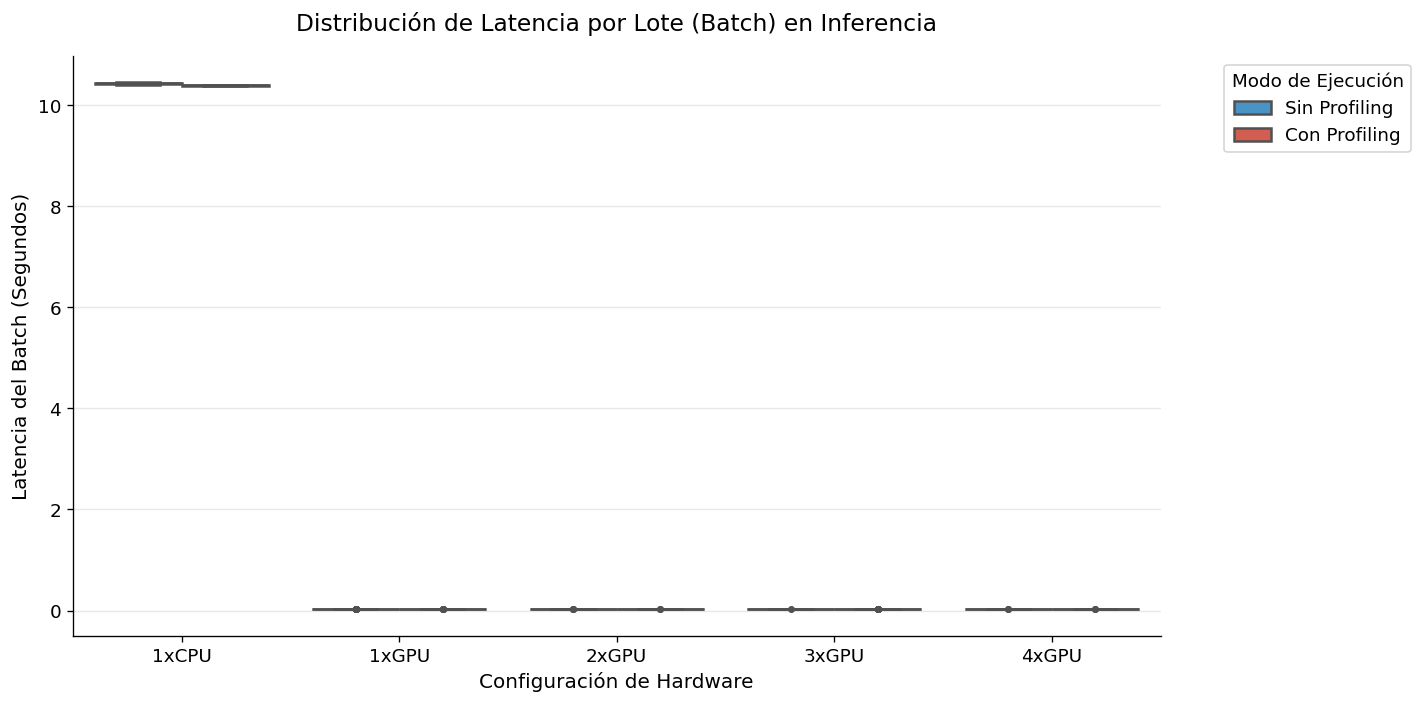

In [32]:
def extraer_latencias_steps():
    datos_steps = []
    
    # Definimos la ruta base utilizando pathlib
    ruta_base = Path("results/image/cuda")
    
    if not ruta_base.exists():
        print(f"ERROR: No se encuentra la ruta en:\n{ruta_base.absolute()}")
        return pd.DataFrame()
        
    print(f"Buscando archivos en:\n{ruta_base.absolute()}\n")
    
    # rglob("*.json") busca en todas las subcarpetas recursivamente
    for filepath in ruta_base.rglob("*.json"):
        try:
            with open(filepath, 'r') as f:
                stats = json.load(f)
            
            # Solo procesamos si existe la lista de métricas por paso
            if 'step_metrics' in stats:
                # Estructura esperada: results/image/cuda/{hardware}/{modo}/stats.json
                # filepath.parent.name -> 'profile' o 'no_profile'
                # filepath.parent.parent.name -> '1xGPU', '1xCPU', etc.
                hw_folder = filepath.parent.parent.name
                modo_folder = filepath.parent.name.lower()
                
                # Asignamos el modo basándonos en el nombre de la carpeta
                if "no_profile" in modo_folder:
                    modo = "Sin Profiling"
                elif "profile" in modo_folder:
                    modo = "Con Profiling"
                else:
                    # Alternativa por si la carpeta se llama diferente
                    is_profile = stats.get('profile', {}).get('enabled', False)
                    modo = "Con Profiling" if is_profile else "Sin Profiling"
                
                for step in stats['step_metrics']:
                    datos_steps.append({
                        "Hardware": hw_folder,
                        "Profiling": modo,
                        "Paso": step.get("step"),
                        "Latencia_Segundos": step.get("batch_latency_seconds")
                    })
        except Exception as e:
            print(f"Error leyendo {filepath.name}: {e}")
                    
    return pd.DataFrame(datos_steps)

# 1. Extraemos los datos
df_latencias = extraer_latencias_steps()

# Ordenamos el hardware para que aparezca de forma secuencial en el gráfico
hardware_order = sorted(df_latencias['Hardware'].unique())

plt.figure(figsize=(12, 6))

# Dibujamos el diagrama de cajas
sns.boxplot(
    data=df_latencias, 
    x="Hardware", 
    y="Latencia_Segundos", 
    hue="Profiling", 
    palette=["#3498db", "#e74c3c"],
    fliersize=3,
    linewidth=1.5,
    order=hardware_order
)

# Configuración estética
plt.title('Distribución de Latencia por Lote (Batch) en Inferencia', fontsize=14, pad=15)
plt.xlabel('Configuración de Hardware', fontsize=12)
plt.ylabel('Latencia del Batch (Segundos)', fontsize=12)
plt.legend(title='Modo de Ejecución', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()